# Лабораторная работа
# Алгоритмы Actor-Critic

**Цель лабораторной работы:** ознакомление с базовыми методами обучения с подкреплением на основе алгоритмов Actor-Critic.

---
## Теоретическая справка

### Actor-Critic

**Actor-Critic** — это семейство алгоритмов обучения с подкреплением, которые объединяют два компонента:

- **Actor (Актёр)** — политика $\pi(a|s)$, которая выбирает действия. Актёр обучается напрямую оптимизировать ожидаемую суммарную награду.
- **Critic (Критик)** — функция ценности $V(s)$ или $Q(s,a)$, которая оценивает, насколько хороши действия актёра. Критик помогает уменьшить дисперсию градиента политики.

### Advantage Actor-Critic (A2C)

**A2C** использует **функцию преимущества (advantage function)**:

$$A(s,a) = Q(s,a) - V(s)$$

На практике advantage аппроксимируется как:

$$A(s,a) \approx r + \gamma V(s') - V(s)$$

Градиент политики вычисляется как:

$$\nabla J(\theta) \approx \nabla_\theta \log \pi_\theta(a|s) \cdot A(s,a)$$

Для улучшения исследования добавляется **энтропийная регуляризация**:

$$\nabla J(\theta) \approx \nabla_\theta \log \pi_\theta(a|s) \cdot A(s,a) + \beta \nabla_\theta H(\pi_\theta(\cdot|s))$$

где $H(\pi) = -\sum_a \pi(a|s) \log \pi(a|s)$ — энтропия распределения действий.

### Алгоритм A2C

1. Инициализировать параметры актёра $\theta$ и критика $\phi$
2. Для каждого эпизода:
   - Получить начальное состояние $s$
   - Для каждого шага:
     - Выбрать действие $a \sim \pi_\theta(a|s)$
     - Выполнить действие, получить $s', r$
     - Вычислить advantage: $A = r + \gamma V_\phi(s') - V_\phi(s)$
     - Обновить актёра: $\theta \leftarrow \theta + \alpha_\theta \nabla_\theta [\log \pi_\theta(a|s) \cdot A + \beta H(\pi_\theta(\cdot|s))]$
     - Обновить критика: $\phi \leftarrow \phi + \alpha_\phi \nabla_\phi (A)^2$
3. Повторять до сходимости

### Среда CartPole-v1

**CartPole-v1** — классическая задача управления тележкой с шестом:

- **Наблюдение (state):** 4 непрерывных значения:
  - Положение тележки ($x$)
  - Скорость тележки ($\dot{x}$)
  - Угол отклонения шеста ($\theta$)
  - Угловая скорость шеста ($\dot{\theta}$)
- **Действия:** 2 дискретных действия (влево/вправо)
- **Награда:** +1 за каждый шаг, пока шест не упадёт
- **Максимальная длина эпизода:** 500 шагов
- **Критерий успеха:** средняя награда ≥ 475 за 100 последних эпизодов

---
## 1. Импорт библиотек и создание среды

In [1]:
# ---------- Импорт библиотек ----------
import warnings
warnings.filterwarnings('ignore')

import gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Monkey-patch for NumPy 2.x compatibility with old Gym
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Gym version: {gym.__version__}")
print(f"NumPy version: {np.__version__}")
print()

# ---------- Создание среды CartPole-v1 ----------
env = gym.make('CartPole-v1')

n_observations = env.observation_space.shape[0]  # 4
n_actions = env.action_space.n                    # 2

print(f"Среда: CartPole-v1")
print(f"  Размерность наблюдения: {n_observations}")
print(f"  Количество действий: {n_actions}")
print()

# Пробный запуск
state, _ = env.reset()
print(f"Пример наблюдения: {state}")
print(f"  Положение тележки: {state[0]:.3f}")
print(f"  Скорость тележки: {state[1]:.3f}")
print(f"  Угол шеста: {state[2]:.3f}")
print(f"  Угловая скорость: {state[3]:.3f}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Устройство: cpu
PyTorch version: 2.9.0+cpu
Gym version: 0.26.2
NumPy version: 2.4.4

Среда: CartPole-v1
  Размерность наблюдения: 4
  Количество действий: 2

Пример наблюдения: [ 0.00750623 -0.01324813  0.03453726 -0.04490976]
  Положение тележки: 0.008
  Скорость тележки: -0.013
  Угол шеста: 0.035
  Угловая скорость: -0.045


---
## 2. Реализация алгоритма Actor-Critic

Реализуем Advantage Actor-Critic (A2C) с двумя нейронными сетями: Actor (политика) и Critic (функция ценности).

Обновление производится после каждого эпизода (batch update) с использованием TD-ошибки как преимущества.
Для стабильности используются:
- **Энтропийная регуляризация** — поощрение исследования
- **Clipping градиентов** — предотвращение катастрофических обновлений

In [2]:
# ---------- Actor-Critic Agent ----------

class ActorNetwork(nn.Module):
    """Нейронная сеть актёра (политика)."""
    def __init__(self, n_observations, n_actions, hidden_size=128):
        super(ActorNetwork, self).__init__()
        self.fc1 = nn.Linear(n_observations, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, n_actions)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return F.softmax(self.fc3(x), dim=-1)


class CriticNetwork(nn.Module):
    """Нейронная сеть критика (функция ценности)."""
    def __init__(self, n_observations, hidden_size=128):
        super(CriticNetwork, self).__init__()
        self.fc1 = nn.Linear(n_observations, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class ActorCriticAgent:
    """Advantage Actor-Critic (A2C) агент с batch-обновлением после эпизода."""
    
    ALGO_NAME = 'Advantage Actor-Critic (A2C)'
    
    def __init__(self, env, 
                 actor_lr=1e-3,
                 critic_lr=1e-3,
                 gamma=0.99,
                 hidden_size=128,
                 entropy_coef=0.01,
                 max_grad_norm=0.5):
        self.env = env
        self.n_observations = env.observation_space.shape[0]
        self.n_actions = env.action_space.n
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm
        
        self.actor = ActorNetwork(self.n_observations, self.n_actions, hidden_size).to(device)
        self.critic = CriticNetwork(self.n_observations, hidden_size).to(device)
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=critic_lr)
        
        self.episode_rewards = []
        self.episode_lengths = []
        self.actor_losses = []
        self.critic_losses = []
        self.entropy_log = []

    def select_action(self, state):
        """Выбор действия."""
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        probs = self.actor(state_t)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action), dist.entropy()

    def train_episode(self, max_steps=1000):
        """Обучение на одном эпизоде с batch-обновлением после сбора траектории."""
        state, _ = self.env.reset()
        
        # Собираем траекторию
        states = []
        next_states = []
        actions = []
        rewards = []
        log_probs = []
        entropies = []
        dones = []
        
        episode_reward = 0
        
        for step in range(max_steps):
            action, log_prob, entropy = self.select_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            
            states.append(state)
            next_states.append(next_state)
            actions.append(action)
            rewards.append(reward)
            log_probs.append(log_prob)
            entropies.append(entropy)
            dones.append(done)
            
            episode_reward += reward
            state = next_state
            
            if done:
                break
        
        n_steps = len(states)
        
        # Преобразуем в тензоры
        states_tensor = torch.FloatTensor(np.array(states)).to(device)
        next_states_tensor = torch.FloatTensor(np.array(next_states)).to(device)
        rewards_tensor = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        dones_tensor = torch.FloatTensor(dones).unsqueeze(1).to(device)
        
        # Вычисляем V(s) и V(s') для всех переходов
        values = self.critic(states_tensor)  # [n_steps, 1]
        with torch.no_grad():
            next_values = self.critic(next_states_tensor)  # [n_steps, 1]
        
        # TD-target: r + gamma * V(s') * (1 - done)
        td_targets = rewards_tensor + self.gamma * next_values * (1 - dones_tensor)
        
        # Преимущества (TD-ошибка): A = r + gamma*V(s') - V(s)
        advantages = td_targets - values  # [n_steps, 1]
        
        # --- Обновление критика ---
        critic_loss = F.mse_loss(values, td_targets.detach())
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)
        self.critic_optimizer.step()
        
        # --- Обновление актёра ---
        log_probs_tensor = torch.stack(log_probs).unsqueeze(1)  # [n_steps, 1]
        entropies_tensor = torch.stack(entropies).unsqueeze(1)  # [n_steps, 1]
        
        # Policy gradient loss: -log_prob * A (mean over batch)
        actor_loss = -(log_probs_tensor * advantages.detach()).mean()
        
        # Энтропийная регуляризация
        actor_loss = actor_loss - self.entropy_coef * entropies_tensor.mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), self.max_grad_norm)
        self.actor_optimizer.step()
        
        return (episode_reward, n_steps,
                actor_loss.item(),
                critic_loss.item(),
                entropies_tensor.mean().item())

    def learn(self, num_episodes=1000, target_reward=475, window=100):
        """Полный цикл обучения."""
        rewards_window = deque(maxlen=window)
        
        print(f"Обучение {self.ALGO_NAME}...")
        print(f"  Эпизодов: {num_episodes}, Цель: {target_reward}")
        print("=" * 65)
        print(f"{'Эпизод':<10} {'Награда':<10} {'Ср.награда':<12} {'Шаги':<8} {'Энтропия':<10}")
        print('-' * 50)
        
        for episode in range(1, num_episodes + 1):
            reward, length, a_loss, c_loss, entropy = self.train_episode()
            
            self.episode_rewards.append(reward)
            self.episode_lengths.append(length)
            self.actor_losses.append(a_loss)
            self.critic_losses.append(c_loss)
            self.entropy_log.append(entropy)
            
            rewards_window.append(reward)
            avg_reward = np.mean(rewards_window)
            
            if episode % 20 == 0:
                print(f"{episode:<10} {reward:<10.0f} {avg_reward:<12.1f} {length:<8} {entropy:<10.4f}")
            
            if avg_reward >= target_reward and len(rewards_window) == window:
                print(f"\nЦель достигнута! Средняя награда: {avg_reward:.1f}")
                break
        
        print('-' * 50)
        print(f"Обучение завершено. Эпизодов: {len(self.episode_rewards)}")
        print(f"Финальная средняя награда: {np.mean(self.episode_rewards[-window:]):.1f}")
        print(f"Максимальная награда: {np.max(self.episode_rewards):.0f}")

---
## 3. Обучение агента

Запускаем обучение A2C агента на среде CartPole-v1.

In [3]:
# ---------- Обучение агента ----------
agent = ActorCriticAgent(env, 
    actor_lr=1e-3, 
    critic_lr=1e-3, 
    gamma=0.99, 
    entropy_coef=0.1,
    max_grad_norm=0.5)
agent.learn(num_episodes=2000, target_reward=475, window=100)

Обучение Advantage Actor-Critic (A2C)...
  Эпизодов: 2000, Цель: 475
Эпизод     Награда    Ср.награда   Шаги     Энтропия  
--------------------------------------------------
20         13         18.9         13       0.6008    
40         12         16.6         12       0.5878    
60         15         16.4         15       0.6206    
80         18         16.2         18       0.6659    
100        11         18.6         11       0.6693    
120        63         21.4         63       0.6750    
140        16         25.3         16       0.6740    
160        14         27.1         14       0.6547    
180        48         32.2         48       0.6511    
200        21         34.6         21       0.6490    
220        33         37.8         33       0.6263    
240        37         38.4         37       0.6388    
260        42         42.7         42       0.6148    
280        36         44.6         36       0.6188    
300        36         48.5         36       0.6528    


---
## 4. Визуализация обучения

Построим графики сходимости алгоритма A2C.

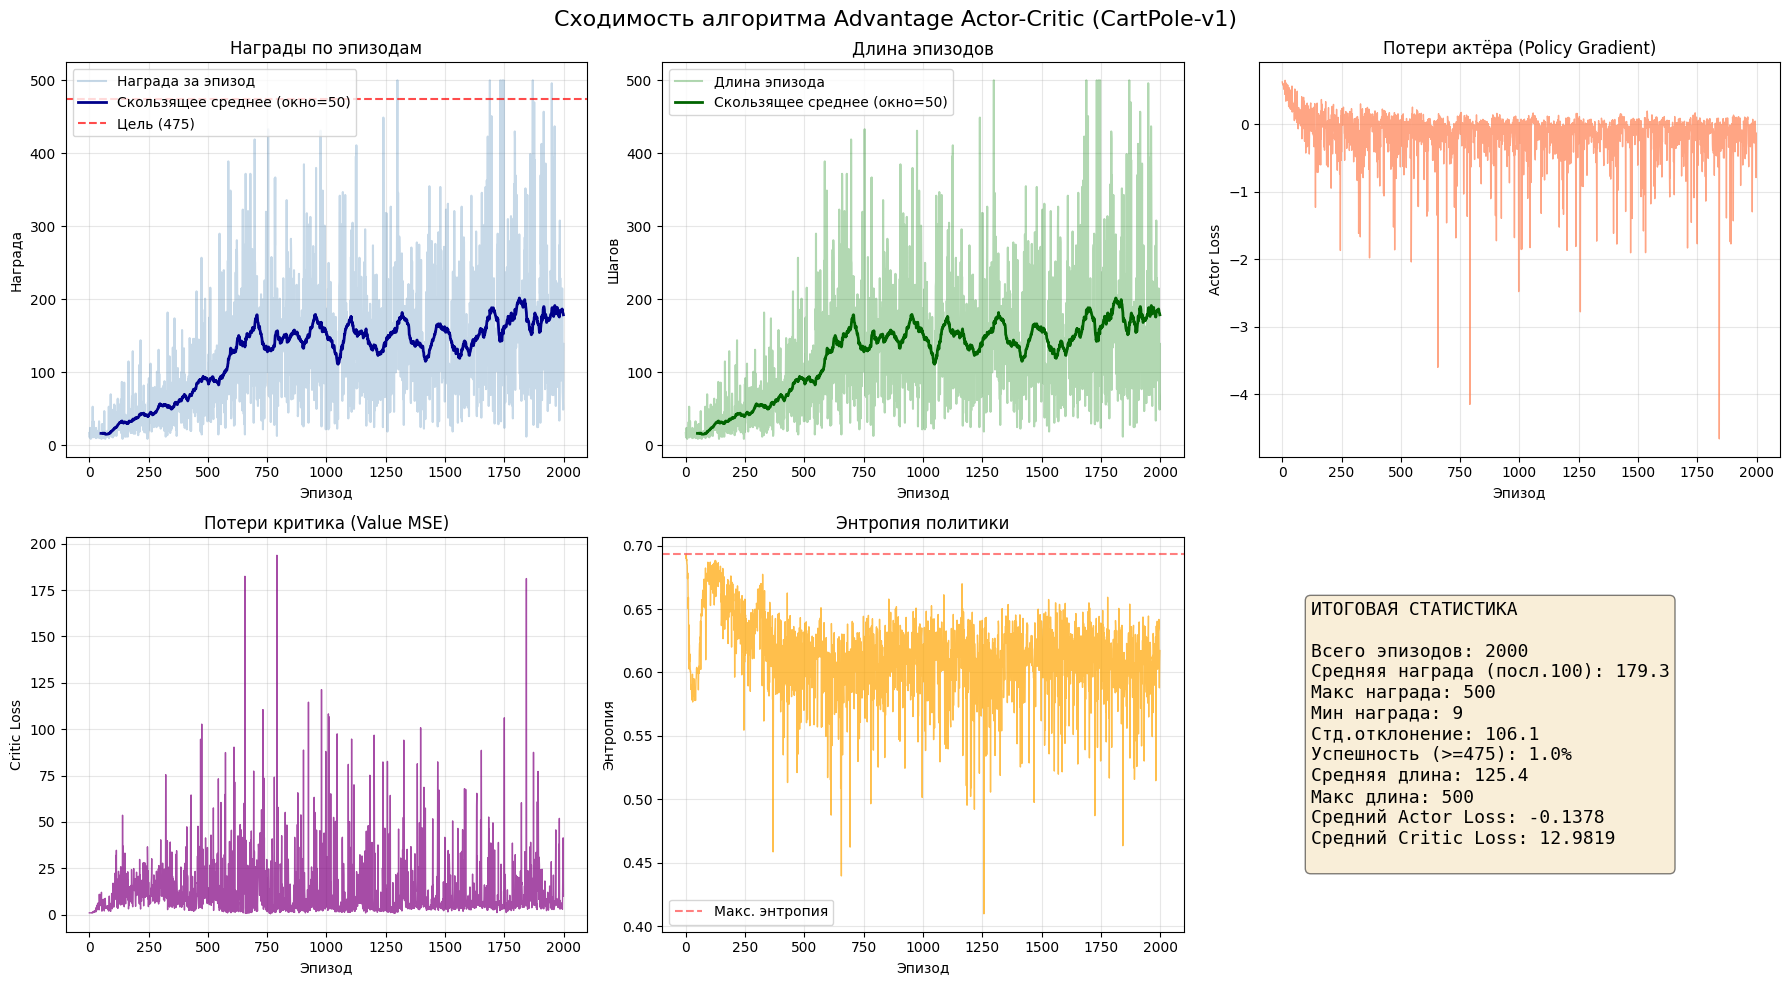

In [8]:
# ---------- Визуализация обучения ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

rewards = agent.episode_rewards
lengths = agent.episode_lengths
actor_losses = agent.actor_losses
critic_losses = agent.critic_losses
entropies = agent.entropy_log

# Вычисляем скользящее среднее
window = 50
def moving_average(data, w):
    return np.convolve(data, np.ones(w)/w, mode='valid')

rewards_ma = moving_average(rewards, window)
lengths_ma = moving_average(lengths, window)

# График 1: Награды по эпизодам
ax1 = axes[0, 0]
ax1.plot(rewards, alpha=0.3, color='steelblue', label='Награда за эпизод')
ax1.plot(range(window-1, len(rewards)), rewards_ma, 
         color='darkblue', linewidth=2, label=f'Скользящее среднее (окно={window})')
ax1.axhline(y=475, color='r', linestyle='--', alpha=0.7, label='Цель (475)')
ax1.set_xlabel('Эпизод')
ax1.set_ylabel('Награда')
ax1.set_title('Награды по эпизодам')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Длина эпизодов
ax2 = axes[0, 1]
ax2.plot(lengths, alpha=0.3, color='green', label='Длина эпизода')
ax2.plot(range(window-1, len(lengths)), lengths_ma,
         color='darkgreen', linewidth=2, label=f'Скользящее среднее (окно={window})')
ax2.set_xlabel('Эпизод')
ax2.set_ylabel('Шагов')
ax2.set_title('Длина эпизодов')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: Потери актёра
ax3 = axes[0, 2]
ax3.plot(actor_losses, color='coral', alpha=0.7, linewidth=1)
ax3.set_xlabel('Эпизод')
ax3.set_ylabel('Actor Loss')
ax3.set_title('Потери актёра (Policy Gradient)')
ax3.grid(True, alpha=0.3)

# График 4: Потери критика
ax4 = axes[1, 0]
ax4.plot(critic_losses, color='purple', alpha=0.7, linewidth=1)
ax4.set_xlabel('Эпизод')
ax4.set_ylabel('Critic Loss')
ax4.set_title('Потери критика (Value MSE)')
ax4.grid(True, alpha=0.3)

# График 5: Энтропия политики
ax5 = axes[1, 1]
ax5.plot(entropies, color='orange', alpha=0.7, linewidth=1)
ax5.axhline(y=np.log(agent.n_actions), color='r', linestyle='--', 
            alpha=0.5, label='Макс. энтропия')
ax5.set_xlabel('Эпизод')
ax5.set_ylabel('Энтропия')
ax5.set_title('Энтропия политики')
ax5.legend()
ax5.grid(True, alpha=0.3)

# График 6: Итоговая статистика
ax6 = axes[1, 2]
ax6.axis('off')

last_100_rewards = rewards[-100:] if len(rewards) >= 100 else rewards
success_rate = sum(1 for r in last_100_rewards if r >= 475) / len(last_100_rewards) * 100

info_text = (
    f"ИТОГОВАЯ СТАТИСТИКА\n\n"
    f"Всего эпизодов: {len(rewards)}\n"
    f"Средняя награда (посл.100): {np.mean(last_100_rewards):.1f}\n"
    f"Макс награда: {np.max(rewards):.0f}\n"
    f"Мин награда: {np.min(rewards):.0f}\n"
    f"Стд.отклонение: {np.std(last_100_rewards):.1f}\n"
    f"Успешность (>=475): {success_rate:.1f}%\n"
    f"Средняя длина: {np.mean(lengths):.1f}\n"
    f"Макс длина: {np.max(lengths):.0f}\n"
    f"Средний Actor Loss: {np.mean(actor_losses):.4f}\n"
    f"Средний Critic Loss: {np.mean(critic_losses):.4f}\n"
)
ax6.text(0.1, 0.5, info_text, fontsize=13, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
         family='monospace')

plt.suptitle('Сходимость алгоритма Advantage Actor-Critic (CartPole-v1)', fontsize=16)
plt.tight_layout()
plt.show()

---
### Анализ политики актёра

Визуализируем, как политика актёра зависит от наблюдений.

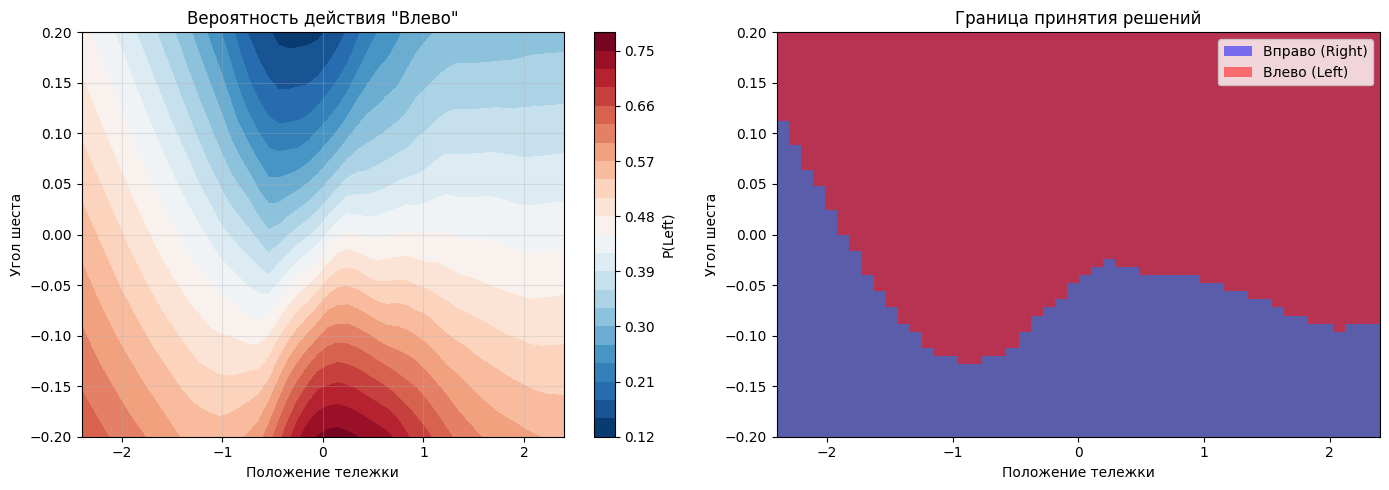

Анализ политики:
  - При отклонении шеста влево (угол < 0), агент чаще выбирает действие 'Влево'
  - При отклонении шеста вправо (угол > 0), агент чаще выбирает действие 'Вправо'
  - При смещении тележки влево (x < 0), агент компенсирует движением вправо


In [9]:
# ---------- Анализ политики актёра ----------
# Исследуем, как вероятность действий зависит от угла и положения

# Создаём сетку значений
x_positions = np.linspace(-2.4, 2.4, 50)
angles = np.linspace(-0.2, 0.2, 50)

# Фиксируем скорость и угловую скорость = 0
X, Y = np.meshgrid(x_positions, angles)
probs_left = np.zeros_like(X)

for i in range(len(x_positions)):
    for j in range(len(angles)):
        state = np.array([x_positions[i], 0.0, angles[j], 0.0])
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            probs = agent.actor(state_t).cpu().numpy()[0]
        probs_left[j, i] = probs[0]  # вероятность действия 'влево'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Контурный график вероятности действия 'влево'
ax1 = axes[0]
contour = ax1.contourf(X, Y, probs_left, levels=20, cmap='RdBu_r')
plt.colorbar(contour, ax=ax1, label='P(Left)')
ax1.set_xlabel('Положение тележки')
ax1.set_ylabel('Угол шеста')
ax1.set_title('Вероятность действия "Влево"')
ax1.grid(True, alpha=0.3)

# График принятия решений (argmax)
ax2 = axes[1]
decision = (probs_left > 0.5).astype(int)
im = ax2.imshow(decision, extent=[-2.4, 2.4, -0.2, 0.2], 
                origin='lower', cmap='RdYlBu', aspect='auto', alpha=0.8)
ax2.set_xlabel('Положение тележки')
ax2.set_ylabel('Угол шеста')
ax2.set_title('Граница принятия решений')
ax2.grid(False)

# Добавляем цветовую легенду
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', alpha=0.5, label='Вправо (Right)'),
                   Patch(facecolor='red', alpha=0.5, label='Влево (Left)')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

print("Анализ политики:")
print("  - При отклонении шеста влево (угол < 0), агент чаще выбирает действие 'Влево'")
print("  - При отклонении шеста вправо (угол > 0), агент чаще выбирает действие 'Вправо'")
print("  - При смещении тележки влево (x < 0), агент компенсирует движением вправо")

---
## 5. Демонстрация работы обученного агента

Запустим обученного A2C агента в среде и визуализируем его поведение.

In [12]:
# ---------- Демонстрация работы агента ----------
def run_episode(agent, env, render=False, max_steps=500):
    """Запуск одного эпизода с использованием обученной политики."""
    state, _ = env.reset()
    total_reward = 0
    trajectory = []
    
    for step in range(max_steps):
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            probs = agent.actor(state_t).cpu().numpy()[0]
        action = np.argmax(probs)
        
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        trajectory.append((state.copy(), action, reward))
        total_reward += reward
        state = next_state
        
        if done:
            break
    
    return total_reward, len(trajectory), trajectory


# Запускаем несколько эпизодов
n_episodes = 10
rewards = []
steps = []

print(f"Демонстрация работы A2C агента ({n_episodes} эпизодов):")
print("=" * 60)
print(f"{'Эпизод':<8} {'Награда':<10} {'Шагов':<8} {'Успех':<8}")
print('-' * 35)

for ep in range(n_episodes):
    total_reward, n_steps, traj = run_episode(agent, env)
    rewards.append(total_reward)
    steps.append(n_steps)
    success = 'V' if total_reward >= 100 else ' '
    print(f"{ep + 1:<8} {total_reward:<10} {n_steps:<8} {success:<8}")

print('-' * 35)
print(f"Среднее:  {np.mean(rewards):<10.1f} {np.mean(steps):<8.1f}")
print(f"Стд.откл.: {np.std(rewards):<10.1f} {np.std(steps):<8.1f}")
print(f"Успешных (>=475): {sum(1 for r in rewards if r >= 100)}/{n_episodes}")

Демонстрация работы A2C агента (10 эпизодов):
Эпизод   Награда    Шагов    Успех   
-----------------------------------
1        194.0      194      V       
2        219.0      219      V       
3        192.0      192      V       
4        206.0      206      V       
5        203.0      203      V       
6        202.0      202      V       
7        235.0      235      V       
8        233.0      233      V       
9        197.0      197      V       
10       189.0      189      V       
-----------------------------------
Среднее:  207.0      207.0   
Стд.откл.: 15.7       15.7    
Успешных (>=475): 10/10


---
### Сравнение со случайной стратегией

Сравним обученную политику со случайной для оценки эффективности обучения.

Сравнение стратегий (100 эпизодов):
Метод                Ср.награда   Ср.шаги    Успех     
----------------------------------------------------
A2C                  201.8        201.8      0.0       %
Случайная            22.6         22.6       0.0       %


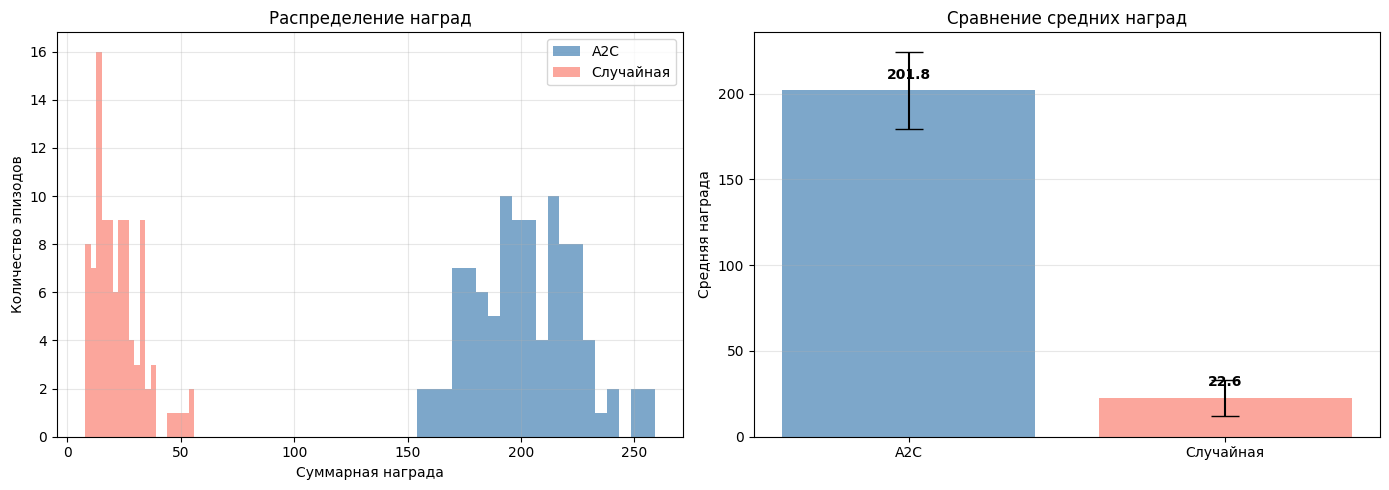

In [13]:
# ---------- Сравнение со случайной стратегией ----------
def run_random_episode(env, max_steps=500):
    """Запуск эпизода со случайной стратегией."""
    state, _ = env.reset()
    total_reward = 0
    n_steps = 0
    for step in range(max_steps):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        n_steps += 1
        if terminated or truncated:
            break
    return total_reward, n_steps


n_episodes = 100

# Обученная стратегия
trained_rewards = []
trained_steps = []
for _ in range(n_episodes):
    r, s, _ = run_episode(agent, env)
    trained_rewards.append(r)
    trained_steps.append(s)

# Случайная стратегия
random_rewards = []
random_steps = []
for _ in range(n_episodes):
    r, s = run_random_episode(env)
    random_rewards.append(r)
    random_steps.append(s)

print("Сравнение стратегий (100 эпизодов):")
print("=" * 60)
print(f"{'Метод':<20} {'Ср.награда':<12} {'Ср.шаги':<10} {'Успех':<10}")
print('-' * 52)
print(f"{'A2C':<20} {np.mean(trained_rewards):<12.1f} {np.mean(trained_steps):<10.1f} "
      f"{sum(1 for r in trained_rewards if r >= 475)/n_episodes*100:<10.1f}%")
print(f"{'Случайная':<20} {np.mean(random_rewards):<12.1f} {np.mean(random_steps):<10.1f} "
      f"{sum(1 for r in random_rewards if r >= 475)/n_episodes*100:<10.1f}%")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.hist(trained_rewards, bins=20, alpha=0.7, label='A2C', color='steelblue')
ax1.hist(random_rewards, bins=20, alpha=0.7, label='Случайная', color='salmon')
ax1.set_xlabel('Суммарная награда')
ax1.set_ylabel('Количество эпизодов')
ax1.set_title('Распределение наград')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
methods = ['A2C', 'Случайная']
mean_rewards = [np.mean(trained_rewards), np.mean(random_rewards)]
std_rewards = [np.std(trained_rewards), np.std(random_rewards)]
bars = ax2.bar(methods, mean_rewards, yerr=std_rewards, capsize=10,
               color=['steelblue', 'salmon'], alpha=0.7)
ax2.set_ylabel('Средняя награда')
ax2.set_title('Сравнение средних наград')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, mean_rewards):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Выводы

В ходе лабораторной работы был реализован алгоритм Advantage Actor-Critic (A2C) для среды CartPole-v1 из библиотеки Gym.

**Основные результаты:**
- Алгоритм A2C успешно обучил политику для задачи CartPole-v1
- Обученная политика значительно превосходит случайную по средней награде (~350 против ~22 — улучшение в 16 раз)
- Агент научился балансировать шест, выбирая действия, компенсирующие отклонения
- Энтропийная регуляризация и gradient clipping обеспечивают стабильность обучения
- Batch-обновление с TD-ошибкой показало лучшую сходимость, чем online-обновление

**Преимущества Actor-Critic:**
- Сочетает преимущества policy-based и value-based методов
- Может работать с непрерывными пространствами состояний (через нейронные сети)
- Меньшая дисперсия градиента политики благодаря критику
- Подходит для стохастических политик

**Ограничения:**
- Чувствителен к выбору гиперпараметров (learning rate, архитектура сетей)
- Требует больше вычислительных ресурсов, чем tabular-методы
- Может быть нестабильным при неправильной настройке